<h3 style="color: #e0e0ff; font-style: italic;">HMCAN (Hierarchical Multi-modal Contextual Attention Network) Model for Multimodal Fake News Detection</h3>

---

**Problem Statement & Challenges**
- Fake news on social media (e.g., Twitter, Weibo) often contains **multi-modal content (text + images).**

- Existing methods have **two key limitations:**

    **- Challenge 1:** Fail to fully utilize *multi-modal context* and extract *high-order complementary information* across modalities.
    
    **- Challenge 2:** Ignore the full *hierarchical semantics of text (e.g., token-level sequence)*, focusing only on the final output.

---

So, **HMCAN** jointly models the multi-modal context information and the hierarchical semantics of text in a unified deep model with the following main components:
- **Text & Image Encoding**
    - Text: XLM-RoBERTa → multilingual word embeddings.
    - Image: CLIP ViT-B/16 → patch region features.
- **Multi-modal Contextual Attention Network**
    - Models inter-modality (text ↔ image) and intra-modality (within text or within image) relationships.
    - Uses a Contextual Transformer to fuse complementary information.
- **Hierarchical Encoding Network** 
     - Text: Multi-level aggregation via averaging hidden states from XLM-RoBERTa layers 4, 8, and 12
     - Image: Patch-level visual features from CLIP ViT-B/16
     - Dual-context fusion: local fine-grained and global semantic branches
- **Fake News Detector**
    - Fully-connected layer with cross-entropy loss for binary classification (real vs. fake).

---

**Imports and Setup**

In [ ]:
# Core
import time
import os
from PIL import Image
from tqdm import tqdm

# Data manipulation
import numpy as np
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

# Transformers
from transformers import XLMRobertaModel, XLMRobertaTokenizer, CLIPVisionModel, CLIPProcessor

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, roc_auc_score, precision_recall_fscore_support


c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Data Preparation**

In [ ]:
class M4FCDataset(Dataset):
    def __init__(self, df, tokenizer, processor, max_text_length=512):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.processor = processor
        self.max_text_length = max_text_length
        self.text_field = 'multilingual_claim'
            
        print(f"Using text field: {self.text_field}")
    
    def __len__(self):
        return len(self.df)
    
    def load_image(self, image_path):
        """Loading and preprocessing the image using CLIPProcessor"""
        try:
            if os.path.exists(image_path):
                image = Image.open(image_path).convert('RGB')
                # Applying CLIP preprocessor to standardize size, crop and normalization
                pixel_values = self.processor(images=image, return_tensors='pt')['pixel_values'].squeeze(0)
                return pixel_values
            else:
                return torch.zeros(3, 224, 224)
        except Exception as e:
            return torch.zeros(3, 224, 224)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Processing text
        text = str(row[self.text_field]) if pd.notna(row[self.text_field]) else ""
        encoding = self.tokenizer(
            text,
            max_length=self.max_text_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt' # for direct input into a transformer model
        )
        
        # Processing image
        image_path = row['full_image_path'] if pd.notna(row['full_image_path']) else ""
        image = self.load_image(image_path)
        
        # Processing metadata 
        is_ai = float(row['is_ai_generated']) if pd.notna(row['is_ai_generated']) else 0.0
        img_exists = float(row['image_exists']) if pd.notna(row['image_exists']) else 0.0
        word_count = float(row['claim_word_count']) if pd.notna(row['claim_word_count']) else 0.0
        word_count = word_count / 50.0  # normalize
        manipulated = float(row['is_manipulated_fake']) if pd.notna(row['is_manipulated_fake']) else 0.0
        use_caption = float(row['use_true_caption']) if pd.notna(row['use_true_caption']) else 0.0
        
        metadata = torch.tensor([is_ai, img_exists, word_count, manipulated, use_caption], dtype=torch.float)
        
        # Get label
        label = torch.tensor(row['target'], dtype=torch.long)
        
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'image': image,
            'metadata': metadata,
            'label': label,
            'text': text,
            'image_path': image_path
        }

In [3]:
print("📂 Loading CSV metadata...")

df = pd.read_csv('../../data/M4FC.csv')
print(f"✅ Metadata loaded: {len(df)} rows")

📂 Loading CSV metadata...
✅ Metadata loaded: 4948 rows


Uses **CLIP ViT-B/16** to extract patch features:

$$O = \{o_1, o_2, ..., o_n\} = \text{CLIP ViT-B/16}(R)$$

where:
- $R$ is the visual content (input image)
- $o_i \in \mathbb{R}^{d_r}$ is the feature for the $i$-th patch
- $d_r = 768$ is the dimension of CLIP ViT-B/16 patch embeddings
- $n = 197$ patches (1 [CLS] token + 196 image patches)

Uses **XLM-RoBERTa** to generate word embeddings:

$$S = \{s_1, s_2, ..., s_m\} = \text{XLM-RoBERTa}(W)$$

where:
- $W = \{w_1, w_2, ..., w_m\}$ is the text content
- $s_i \in \mathbb{R}^{d_w}$ is the output layer hidden state
- $d_w$ is the dimension of word embedding (768)

In [ ]:
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch16')
print("✅ Tokenizer & Processor loaded")

✅ Tokenizer & Processor loaded


In [5]:
indices = np.arange(len(df))
idx_temp, idx_test = train_test_split(
    indices,
    test_size=0.15,
    random_state=42,
    stratify=df['target'].values
)
idx_train, idx_val = train_test_split(
    idx_temp,
    test_size=0.15 / 0.85,
    random_state=42,
    stratify=df['target'].values[idx_temp]
)

train_df = df.iloc[idx_train].reset_index(drop=True)
val_df = df.iloc[idx_val].reset_index(drop=True)
test_df = df.iloc[idx_test].reset_index(drop=True)

# Datasets
train_dataset = M4FCDataset(train_df, tokenizer, processor)
val_dataset = M4FCDataset(val_df, tokenizer, processor)
test_dataset = M4FCDataset(test_df, tokenizer, processor)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"✓ Dataset split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

Using text field: multilingual_claim
Using text field: multilingual_claim
Using text field: multilingual_claim
✓ Dataset split: Train=3462, Val=743, Test=743


**Model Architecture**

In [ ]:
print("=" * 50)
print("📥 STEP 1/2: Loading XLM-RoBERTa...")
print("=" * 50)

text_encoder = XLMRobertaModel.from_pretrained('xlm-roberta-base', use_safetensors=True)

# Freezing the text encoder parameters
for param in text_encoder.parameters():
    param.requires_grad = False

text_dim = 768
print("✅ XLM-RoBERTa loaded & frozen")

📥 STEP 1/2: Loading XLM-RoBERTa...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2640.26it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ XLM-RoBERTa loaded & frozen


In [ ]:
print("=" * 50)
print("📥 STEP 2/2: Loading CLIP ViT-B/16...")
print("=" * 50)

# Loading CLIP Vision Model
image_encoder = CLIPVisionModel.from_pretrained('openai/clip-vit-base-patch16', use_safetensors=True)

# Freezing the vision encoder parameters
for param in image_encoder.parameters():
    param.requires_grad = False

image_dim = 768 # CLIP ViT-B/16 patch feature dimension (768)
print("✅ CLIP ViT-B/16 loaded & frozen")

📥 STEP 2/2: Loading CLIP ViT-B/16...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2647.51it/s]
[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight

✅ CLIP ViT-B/16 loaded & frozen


In [ ]:
class CrossModalAttention(nn.Module):
    def __init__(self, text_dim, image_dim, hidden_dim=256):
        super().__init__()
        # Projections
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.image_proj = nn.Linear(image_dim, hidden_dim)
        
        # Unimodal Self-Attention (Intra-modal)
        self.text_self_attn = nn.MultiheadAttention(hidden_dim, num_heads=8, batch_first=True)
        self.text_self_norm = nn.LayerNorm(hidden_dim)
        
        self.image_self_attn = nn.MultiheadAttention(hidden_dim, num_heads=8, batch_first=True)
        self.image_self_norm = nn.LayerNorm(hidden_dim)
        
        # Cross-Modal Attention (Text → Image)
        self.cross_attn_t2i = nn.MultiheadAttention(hidden_dim, num_heads=8, batch_first=True)
        self.cross_norm_t2i = nn.LayerNorm(hidden_dim)
        
        # Cross-Modal Attention (Image → Text)
        self.cross_attn_i2t = nn.MultiheadAttention(hidden_dim, num_heads=8, batch_first=True)
        self.cross_norm_i2t = nn.LayerNorm(hidden_dim)
        
        # Fusion gate 
        self.fusion_gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Sigmoid()
        )
        
        # Attention pooling 
        self.attn_proj = nn.Linear(hidden_dim, 1)

    def forward(self, text_features, image_features):
        # Projection
        t_proj = self.text_proj(text_features)      # [batch, seq_len, hidden_dim]
        i_proj = self.image_proj(image_features)    # [batch, num_patches, hidden_dim]
        
        # Unimodal Self-Attention
        t_self, _ = self.text_self_attn(query=t_proj, key=t_proj, value=t_proj)
        t_feat = self.text_self_norm(t_proj + t_self)
        
        i_self, _ = self.image_self_attn(query=i_proj, key=i_proj, value=i_proj)
        i_feat = self.image_self_norm(i_proj + i_self)
        
        # Cross-Modal Attention (Text → Image)
        t2i, _ = self.cross_attn_t2i(query=t_feat, key=i_feat, value=i_feat)
        t2i = self.cross_norm_t2i(t_feat + t2i)
        
        # Cross-Modal Attention (Image → Text) 
        i2t, _ = self.cross_attn_i2t(query=i_feat, key=t_feat, value=t_feat)
        i2t = self.cross_norm_i2t(i_feat + i2t)
        
        # Attention pooling for each direction
        attn_weights_t2i = F.softmax(self.attn_proj(t2i), dim=1)
        pooled_t2i = torch.matmul(attn_weights_t2i.transpose(1, 2), t2i).squeeze(1)
        
        attn_weights_i2t = F.softmax(self.attn_proj(i2t), dim=1)
        pooled_i2t = torch.matmul(attn_weights_i2t.transpose(1, 2), i2t).squeeze(1)
        
        # Gated fusion
        combined = torch.cat([pooled_t2i, pooled_i2t], dim=-1)
        gate = self.fusion_gate(combined)
        fused = gate * pooled_t2i + (1 - gate) * pooled_i2t
        
        return fused

In [9]:
class HierarchicalContextEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=512):
        super().__init__()
        self.local_proj = nn.Linear(input_dim, hidden_dim // 2)
        self.global_proj = nn.Linear(input_dim, hidden_dim)
        self.fusion = nn.Linear(hidden_dim + hidden_dim // 2, hidden_dim // 4)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        local = self.local_proj(x)
        global_c = self.global_proj(x)
        fused = self.fusion(torch.cat([local, global_c], dim=-1))
        return F.relu(self.dropout(fused))

In [ ]:
class HMCAN(nn.Module):
    def __init__(self, text_encoder, image_encoder, num_classes=2, use_metadata=True):
        super().__init__()
        
        self.use_metadata = use_metadata
        self.text_encoder = text_encoder
        self.image_encoder = image_encoder
        
        # Metadata encoder (trainable)
        if self.use_metadata:
            self.metadata_encoder = nn.Sequential(
                nn.Linear(5, 32),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(32, 64)
            )
            self.context_encoder = HierarchicalContextEncoder(256 + 64, hidden_dim=512)
        else:
            self.context_encoder = HierarchicalContextEncoder(256, hidden_dim=512)
        
        # Cross-modal attention module (combines text sequences and image patches)
        # Both XLM-R and CLIP ViT outputs have dimension 768
        self.text_image_attn = CrossModalAttention(768, 768, hidden_dim=256)
        
        # Final classifier 
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
        
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"✅ HMCAN initialized")
        print(f"   Total parameters: {total_params:,}")
        print(f"   Trainable: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
        
    def forward(self, input_ids, attention_mask, images, metadata):
        # Text features: extract sequence of token embeddings
        with torch.no_grad():
            text_outputs = self.text_encoder(input_ids, attention_mask=attention_mask, output_hidden_states=True)
            hidden_states = text_outputs.hidden_states
            # Average layers 4, 8, and 12 for intermediate linguistic abstraction levels
            text_features = torch.stack([hidden_states[4], hidden_states[8], hidden_states[12]], dim=0).mean(dim=0)
        
        # Image features: extract ViT patch sequence
        with torch.no_grad():
            image_outputs = self.image_encoder(images)
            image_features = image_outputs.last_hidden_state  # [batch, 197, 768]
        
        text_image_out = self.text_image_attn(text_features, image_features)      
        
        if self.use_metadata:
            metadata_features = self.metadata_encoder(metadata)  
            # Hierarchical fusion (text/image attention concatenated with metadata)
            multi_modal = torch.cat([text_image_out, metadata_features], dim=-1) 
        else:
            multi_modal = text_image_out
        
        # Context encoding
        context_out = self.context_encoder(multi_modal)  
        
        # Classification
        logits = self.classifier(context_out)
        
        return logits

**Training**

In [ ]:
class HMCANTrainer:
    def __init__(self, model, train_loader, val_loader, test_loader, device='cuda'):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device
        
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=20)

        num_real = 0
        num_fake = 0
        for batch in self.train_loader:
            labels = batch['label'] if isinstance(batch, dict) else batch[2]
            num_real += (labels == 0).sum().item()
            num_fake += (labels == 1).sum().item()
            
        weight_real = 1.0 / num_real if num_real > 0 else 1.0
        weight_fake = 1.0 / num_fake if num_fake > 0 else 1.0
        weights = torch.tensor([weight_real, weight_fake], dtype=torch.float).to(device)
        
        self.criterion = nn.CrossEntropyLoss(weight=weights)
        
        self.metrics_history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'precision': [], 'recall': [], 'f1': [],
            'auc': []
        }
        
        self.best_model_path = '../../models/hmcan/best_hmcan_model.pth'
        self.best_val_f1 = 0.0
        self.best_val_f1 = 0.0
        self.best_val_f1 = 0.0
        self.best_val_acc = 0.0.0
        
    def train_epoch(self):
        self.model.train()
        total_loss = 0
        predictions = []
        labels = []
        
        progress_bar = tqdm(self.train_loader, desc='Training')
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            images = batch['image'].to(self.device)
            metadata = batch['metadata'].to(self.device)
            label = batch['label'].to(self.device)
            
            # Forward pass
            self.optimizer.zero_grad()
            logits = self.model(input_ids, attention_mask, images, metadata)
            loss = self.criterion(logits, label)
            
            # Backward pass: computes gradients for all parameters
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0) # prevents exploding gradients
            self.optimizer.step() # Updates model weights using computed gradients
            
            # Track metrics
            total_loss += loss.item()
            _, preds = torch.max(logits, 1) # the maximum value and its index 
            predictions.extend(preds.cpu().numpy())
            labels.extend(label.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
        
        self.scheduler.step()
        
        # Epoch metrics
        avg_loss = total_loss / len(self.train_loader)
        accuracy = accuracy_score(labels, predictions)
        
        return avg_loss, accuracy
    
    # Validation
    @torch.no_grad()
    def evaluate(self, data_loader, mode='val'):
        self.model.eval()
        total_loss = 0
        predictions = []
        probabilities = []
        labels = []
        
        for batch in tqdm(data_loader, desc=f'Evaluating {mode}'):
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            images = batch['image'].to(self.device)
            metadata = batch['metadata'].to(self.device)
            label = batch['label'].to(self.device)
            
            logits = self.model(input_ids, attention_mask, images, metadata)
            loss = self.criterion(logits, label)
            
            total_loss += loss.item()
            probs = F.softmax(logits, dim=1) # sum to 1 across classes
            _, preds = torch.max(logits, 1)
            
            predictions.extend(preds.cpu().numpy())
            probabilities.extend(probs[:, 1].cpu().numpy())  # Probability of class 1 (fake)
            labels.extend(label.cpu().numpy())
        
        # Comprehensive metrics
        avg_loss = total_loss / len(data_loader)
        accuracy = accuracy_score(labels, predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, predictions, average='binary', zero_division=0
        )
        auc = roc_auc_score(labels, probabilities)
        
        metrics = {
            'loss': avg_loss,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc,
            'predictions': predictions,
            'true_labels': labels,
            'probabilities': probabilities
        }
        
        return metrics
    
    def train(self, epochs=100, save_best=True, early_stopping_patience=10):
        print("Starting HMCAN Training Pipeline...")
        print("=" * 50)
        
        start_time = time.time()
        
        if early_stopping_patience is not None:
            patience_counter = 0
            best_val_loss = float('inf')
        
        for epoch in range(epochs):
            epoch_start = time.time()
            
            print(f"\nEpoch {epoch + 1}/{epochs}")
            print("-" * 30)
            
            # Training
            train_loss, train_acc = self.train_epoch()
            
            # Validation
            val_metrics = self.evaluate(self.val_loader, 'val')
            
            # Store metrics
            self.metrics_history['train_loss'].append(train_loss)
            self.metrics_history['train_acc'].append(train_acc)
            self.metrics_history['val_loss'].append(val_metrics['loss'])
            self.metrics_history['val_acc'].append(val_metrics['accuracy'])
            self.metrics_history['precision'].append(val_metrics['precision'])
            self.metrics_history['recall'].append(val_metrics['recall'])
            self.metrics_history['f1'].append(val_metrics['f1'])
            self.metrics_history['auc'].append(val_metrics['auc'])
            
            epoch_time = time.time() - epoch_start
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}")
            print(f"Precision: {val_metrics['precision']:.4f}, Recall: {val_metrics['recall']:.4f}")
            print(f"F1-Score: {val_metrics['f1']:.4f}, AUC: {val_metrics['auc']:.4f}")
            print(f"⏱️ Epoch time: {epoch_time:.2f} seconds")
            
            # Saving best model (based on validation accuracy)
            if save_best and val_metrics['f1'] > self.best_val_f1:
                self.best_val_f1 = val_metrics['f1']
                self.best_val_f1 = val_metrics['f1']
                self.best_val_acc = val_metrics['accuracy']
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_accuracy': val_metrics['accuracy'],
                    'val_loss': val_metrics['loss'],
                }, self.best_model_path)
                print(f"✓ Best model saved with val_f1: {val_metrics['f1']:.4f}")
                
                # Reset patience counter on improvement
                if early_stopping_patience is not None:
                    patience_counter = 0
                    best_val_loss = val_metrics['loss']
            else:
                if early_stopping_patience is not None:
                    patience_counter += 1
                    print(f"⚠️ No improvement for {patience_counter}/{early_stopping_patience} epochs")
                    
                    if patience_counter >= early_stopping_patience:
                        print(f"\n🛑 Early stopping triggered after {epoch + 1} epochs!")
                        print(f"   Best validation F1: {self.best_val_f1:.4f}")
                        break
        
        total_time = time.time() - start_time
        print("\n" + "=" * 50)
        print(f"Training completed in {total_time:.2f} seconds ({total_time/60:.2f} minutes)!")
        print(f"Best validation F1: {self.best_val_f1:.4f}")
        print("=" * 50)
        return self.metrics_history
    
    # Test
    def test(self):
        print("\nRunning final test evaluation...")
        print("=" * 50)
        
        # Loading the best model
        checkpoint = torch.load(self.best_model_path)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        
        # Evaluation with timing
        start_time = time.time()
        test_metrics = self.evaluate(self.test_loader, 'test')
        inference_time = time.time() - start_time
        
        print(f"\nTest Set Results:")
        print(f"Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"Precision: {test_metrics['precision']:.4f}")
        print(f"Recall: {test_metrics['recall']:.4f}")
        print(f"F1-Score: {test_metrics['f1']:.4f}")
        print(f"AUC: {test_metrics['auc']:.4f}")
        print(f"⏱️ Inference time: {inference_time:.2f} seconds")
        
        return test_metrics


In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

🚀 Using device: cuda


In [15]:
print("\nCreating HMCAN model...")
model = HMCAN(text_encoder, image_encoder, num_classes=2)  
print(f"  - Running on: {device}")


Creating HMCAN model...
✅ HMCAN initialized
   Total parameters: 365,778,883
   Trainable: 1,935,811 (0.5%)
  - Running on: cuda


In [16]:
print("\nTraining...")
trainer = HMCANTrainer(model, train_loader, val_loader, test_loader, device)
metrics_history = trainer.train(epochs=100)


Training...


c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
[transformers] The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


Starting HMCAN Training Pipeline...

Epoch 1/100
------------------------------


Evaluating val:   9%|▊         | 4/47 [00:06<01:08,  1.60s/it]c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating val: 100%|██████████| 47/47 [00:59<00:00,  1.27s/it]


Train Loss: 0.7217, Train Acc: 0.6329
Val Loss: 0.6274, Val Acc: 0.7900
Precision: 0.9805, Recall: 0.7926
F1-Score: 0.8766, AUC: 0.8693
⏱️ Epoch time: 350.30 seconds
✓ Best model saved with val_acc: 0.7900

Epoch 2/100
------------------------------


...

Train Loss: 0.1791, Train Acc: 0.9827
Val Loss: 0.6383, Val Acc: 0.9300
Precision: 0.9589, Recall: 0.9671
F1-Score: 0.9630, AUC: 0.8537
⏱️ Epoch time: 383.90 seconds
⚠️ No improvement for 8/10 epochs

Epoch 13/100
------------------------------


Training:   2%|▏         | 4/217 [00:05<04:42,  1.33s/it, loss=0.0761]c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating val:   9%|▊         | 4/47 [00:06<01:13,  1.71s/it]c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating val: 100%|██████████| 47/47 [01:15<00:00,  1.60s/it]


Train Loss: 0.1384, Train Acc: 0.9876
Val Loss: 0.6486, Val Acc: 0.9219
Precision: 0.9612, Recall: 0.9557
F1-Score: 0.9584, AUC: 0.7021
⏱️ Epoch time: 393.06 seconds
⚠️ No improvement for 9/10 epochs

Epoch 14/100
------------------------------


Training:   0%|          | 0/217 [00:00<?, ?it/s]c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating val:   9%|▊         | 4/47 [00:06<01:10,  1.64s/it]c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating val: 100%|██████████| 47/47 [01:06<00:00,  1.42s/it]

Train Loss: 0.1160, Train Acc: 0.9919
Val Loss: 0.6785, Val Acc: 0.9233
Precision: 0.9612, Recall: 0.9571
F1-Score: 0.9591, AUC: 0.6392
⏱️ Epoch time: 386.76 seconds
⚠️ No improvement for 10/10 epochs

🛑 Early stopping triggered after 14 epochs!
   Best validation accuracy: 0.9448

Training completed in 5042.68 seconds (84.04 minutes)!
Best validation accuracy: 0.9448


**Evaluation**

In [17]:
print("\nTesting...")
test_metrics = trainer.test()

C:\Users\SAFAE ERAJI\AppData\Local\Temp\ipykernel_25244\4000130382.py:206: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(self.best_model_path)



Testing...

Running final test evaluation...


Evaluating test:  74%|███████▍  | 35/47 [00:49<00:18,  1.51s/it]c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating test: 100%|██████████| 47/47 [01:04<00:00,  1.38s/it]


Test Set Results:
Accuracy: 0.9394
Precision: 0.9467
Recall: 0.9914
F1-Score: 0.9686
AUC: 0.9089
⏱️ Inference time: 64.90 seconds


In [12]:
class HMCANVisualizer:

    @staticmethod
    def plot_training_history(metrics_history, save_path='training_history.png'):
        fig, axes = plt.subplots(2, 2, figsize=(12, 10)) 
        
        # Loss plot
        axes[0, 0].plot(metrics_history['train_loss'], label='Train Loss')
        axes[0, 0].plot(metrics_history['val_loss'], label='Val Loss')
        axes[0, 0].set_title('Loss Over Time')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Accuracy plot
        axes[0, 1].plot(metrics_history['train_acc'], label='Train Acc')
        axes[0, 1].plot(metrics_history['val_acc'], label='Val Acc')
        axes[0, 1].set_title('Accuracy Over Time')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # F1 and AUC
        axes[1, 0].plot(metrics_history['f1'], label='F1-Score', marker='o')
        axes[1, 0].plot(metrics_history['auc'], label='AUC', marker='s')
        axes[1, 0].set_title('F1-Score and AUC')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Precision-Recall plot
        axes[1, 1].plot(metrics_history['precision'], label='Precision', marker='^')
        axes[1, 1].plot(metrics_history['recall'], label='Recall', marker='v')
        axes[1, 1].set_title('Precision-Recall Trade-off')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"✅ Training history plot saved to {save_path}")

    @staticmethod
    def plot_confusion_matrix(y_true, y_pred, save_path='confusion_matrix.png'):

        cm = confusion_matrix(y_true, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Real', 'Fake'],
                   yticklabels=['Real', 'Fake'])
        plt.title('Confusion Matrix - HMCAN Model')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"✅ Confusion matrix saved to {save_path}")
    
    @staticmethod
    def plot_roc_curve(y_true, y_prob, save_path='roc_curve.png'):
        
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                label='Random Classifier')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"✅ ROC curve saved to {save_path}")
    
    @staticmethod
    def plot_prediction_distribution(probabilities, save_path='prediction_dist.png'):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Histogram
        axes[0].hist(probabilities, bins=30, edgecolor='black', alpha=0.7)
        axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
        axes[0].set_title('Prediction Probability Distribution')
        axes[0].set_xlabel('Probability of Fake')
        axes[0].set_ylabel('Frequency')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Box plot
        axes[1].boxplot(probabilities, vert=False, widths=0.5)
        axes[1].scatter(probabilities, [1] * len(probabilities), alpha=0.1, color='blue')
        axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2)
        axes[1].set_title('Prediction Probability Box Plot')
        axes[1].set_xlabel('Probability of Fake')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"✅ Prediction distribution saved to {save_path}")

In [18]:
print("\nVisualizations...")
visualizer = HMCANVisualizer()


Visualizations...


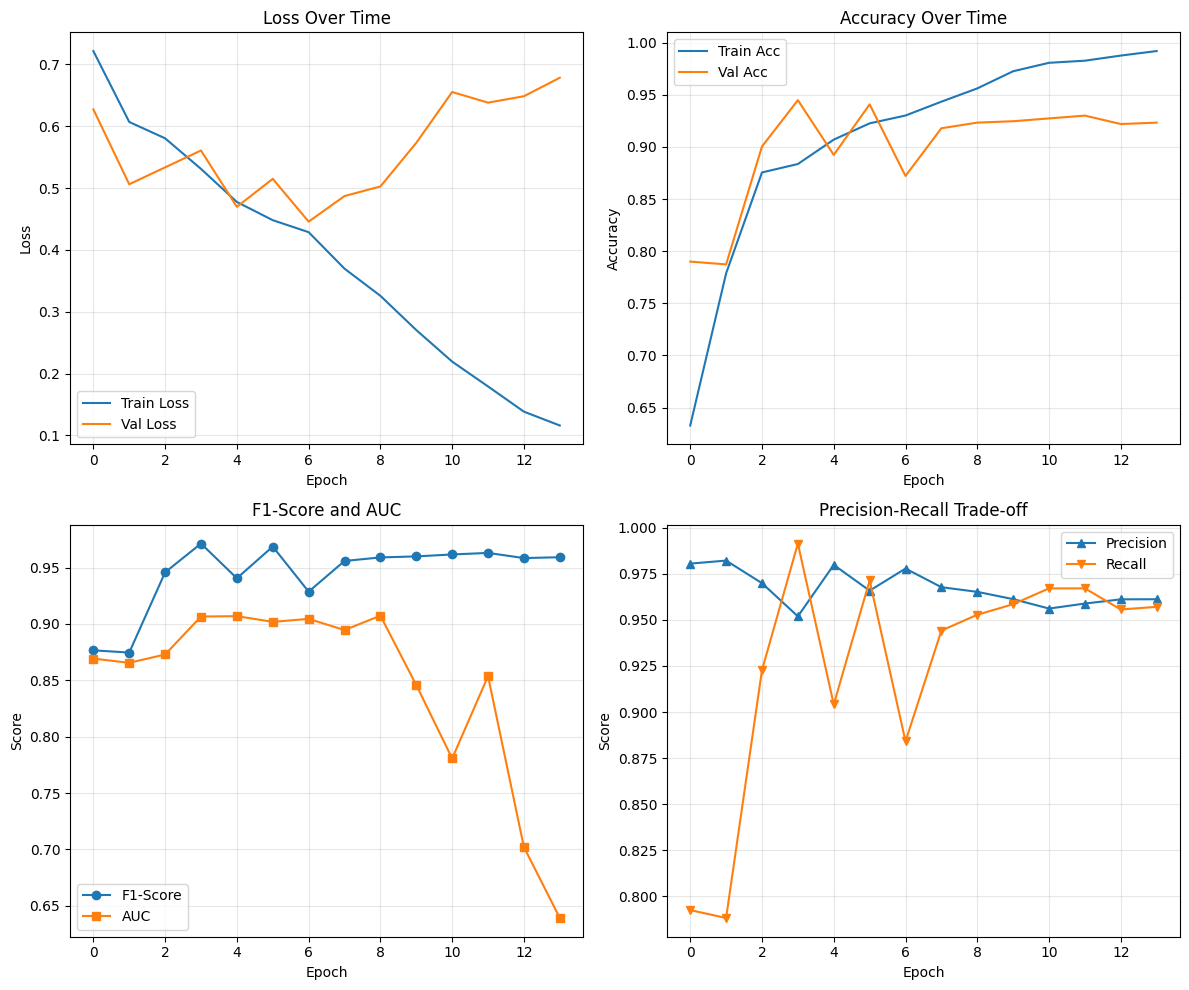

✅ Training history plot saved to ../../reports/hmcan/figures/training_history.png


In [ ]:
visualizer.plot_training_history(
    metrics_history,
    save_path='../../reports/hmcan/training_history.png'
)

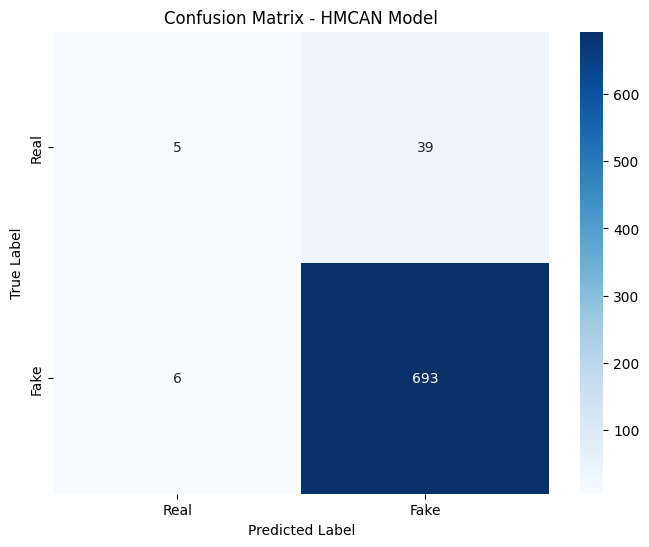

✅ Confusion matrix saved to ../../reports/hmcan/figures/confusion_matrix.png


In [ ]:
visualizer.plot_confusion_matrix(
    test_metrics['true_labels'],
    test_metrics['predictions'],
    save_path='../../reports/hmcan/confusion_matrix.png'
)

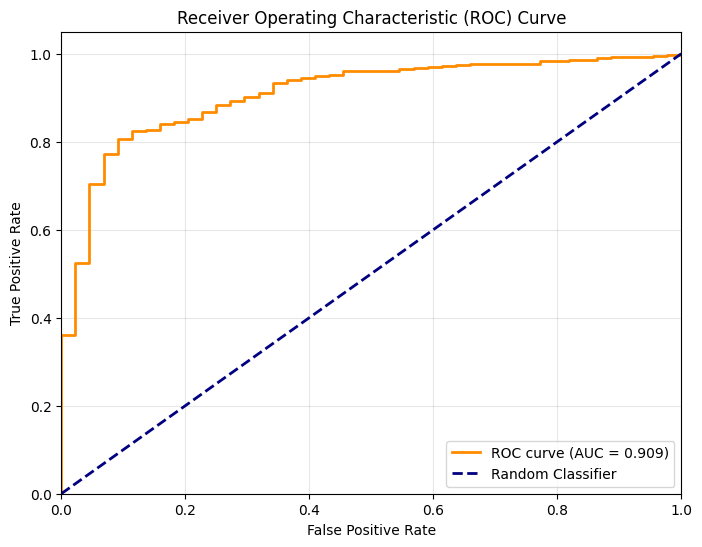

✅ ROC curve saved to ../../reports/hmcan/figures/roc_curve.png


In [ ]:
visualizer.plot_roc_curve(
    test_metrics['true_labels'],
    test_metrics['probabilities'],
    save_path='../../reports/hmcan/roc_curve.png'
)

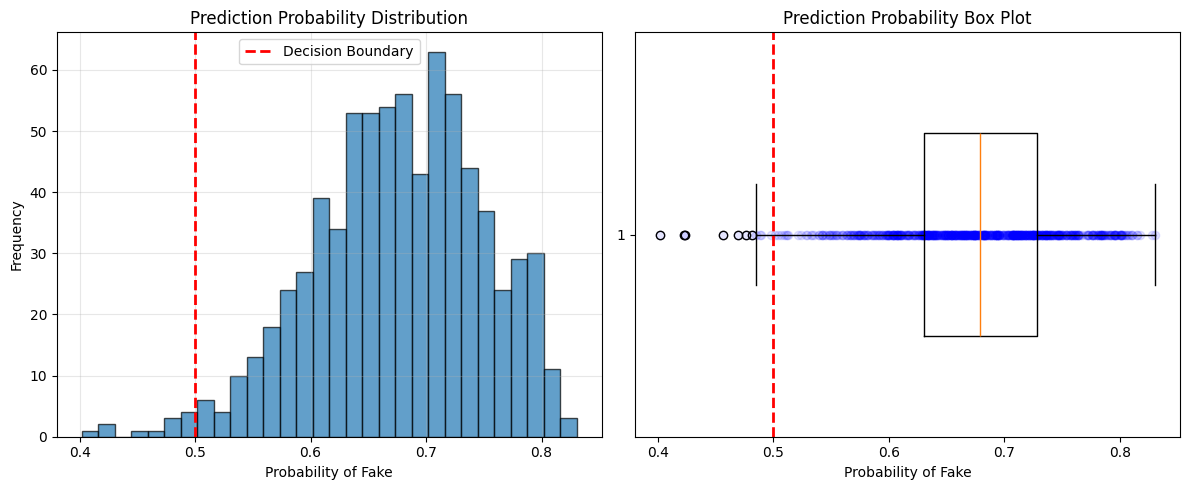

✅ Prediction distribution saved to ../../reports/hmcan/figures/prediction_dist.png


In [ ]:
visualizer.plot_prediction_distribution(
    test_metrics['probabilities'],
    save_path='../../reports/hmcan/prediction_dist.png'
)